In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part III – Sentiment Classification with RNN / LSTM
## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

In this section we load the raw hotel-review dataset, clean the text, visualise the vocabulary,
split the data, tokenise with Keras, and apply percentile-based padding to produce fixed-length sequences.

## Section 1 – Install Dependencies & Mount Drive

Install the `contractions` library (used to expand contractions such as *don't → do not*)
and mount Google Drive so the dataset can be accessed.

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00


## Section 2 – Imports

In [ ]:
import time
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
np.random.seed(42)
random.seed(42)

## Section 3 – Dataset Path

In [ ]:
text_dir = "/content/drive/Shareddrives/AI/2. Hotel Review Dataset/Hotel_Reviews.csv"

## Section 4 – Utility Functions

Define reusable helper functions for plotting training curves and confusion matrices,
following the same style used in Part 2.

In [ ]:
def plot_training_curves(history, title_prefix="Model"):
    """
    Plots accuracy and loss curves side-by-side for a Keras history object.
    Matches the Part 2 style exactly.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs_range, history.history['accuracy'],     label='Training Accuracy',   marker='o')
    ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy',  marker='s')
    ax1.set_title(f"{title_prefix} – Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(epochs_range, history.history['loss'],     label='Training Loss',   marker='o')
    ax2.plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title(f"{title_prefix} – Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title="Confusion Matrix", cmap_name="Blues"):
    """
    Renders a seaborn confusion matrix heatmap.
    Matches the Part 2 style exactly.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap_name,
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_evaluation(model, X_test_pad, y_test_flat, label="Model"):
    """
    Runs inference, prints classification report, plots confusion matrix.
    Returns y_pred array and accuracy score.
    """
    y_pred_probs   = model.predict(X_test_pad, verbose=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    report = classification_report(
        y_test_flat, y_pred_classes,
        target_names=CLASS_LABELS, output_dict=True
    )
    accuracy = report['accuracy']

    print(f"\n{'='*50}")
    print(f"  Classification Report — {label}")
    print(f"{'='*50}")
    print(classification_report(
        y_test_flat, y_pred_classes,
        target_names=CLASS_LABELS
    ))

    plot_confusion_matrix(
        y_test_flat, y_pred_classes,
        class_labels=CLASS_LABELS,
        title=f"Confusion Matrix — {label}"
    )
    return y_pred_classes, accuracy

# Step 1 – Load the Dataset

Load the CSV file with Pandas using `ISO-8859-1` encoding. We inspect the shape and a preview of the first few rows.

In [ ]:
data = pd.read_csv(text_dir, encoding="ISO-8859-1")
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
print("Rating distribution:")
print(data['Rating'].value_counts().sort_index())
print("\nNull values:")
print(data.isnull().sum())
print("\nDataset info:")
data.info()

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Null values:
Review    0
Rating    0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


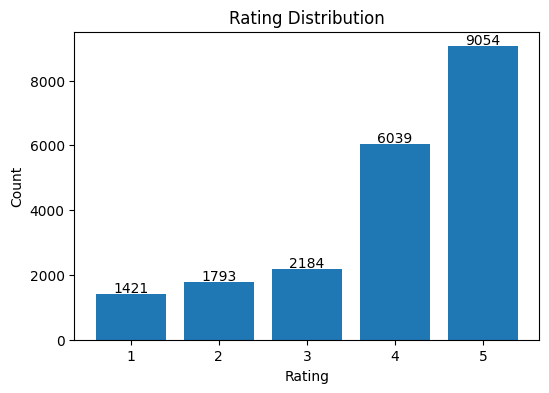

In [ ]:
rating_counts = data['Rating'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")

for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 50, str(v), ha='center')

plt.show()

In [ ]:
data = data[['Review', 'Rating']]
data.dropna(inplace=True)
print("Shape after dropping nulls:", data.shape)
data.head()

Shape after dropping nulls: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


# Step 2 – Text Cleaning

The cleaning pipeline applies the following steps in order:
1. Lowercase all text
2. Expand contractions (*don't → do not*)
3. Remove URLs
4. Remove mentions (`@user`) and hashtags (`#tag`)
5. Remove digits
6. Remove special characters
7. Strip extra whitespace

After cleaning, stopwords are removed and each word is lemmatized.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    text   = clean_text(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

print("Cleaning text — this may take a minute...")
data['cleaned_review'] = data['Review'].apply(preprocess_text)
print("Done.")
data[['Review', 'cleaned_review']].head()

Cleaning text — this may take a minute...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Done.


,Review,cleaned_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


# Step 3 – Visualise Cleaned Data

### 3.1 Word Cloud

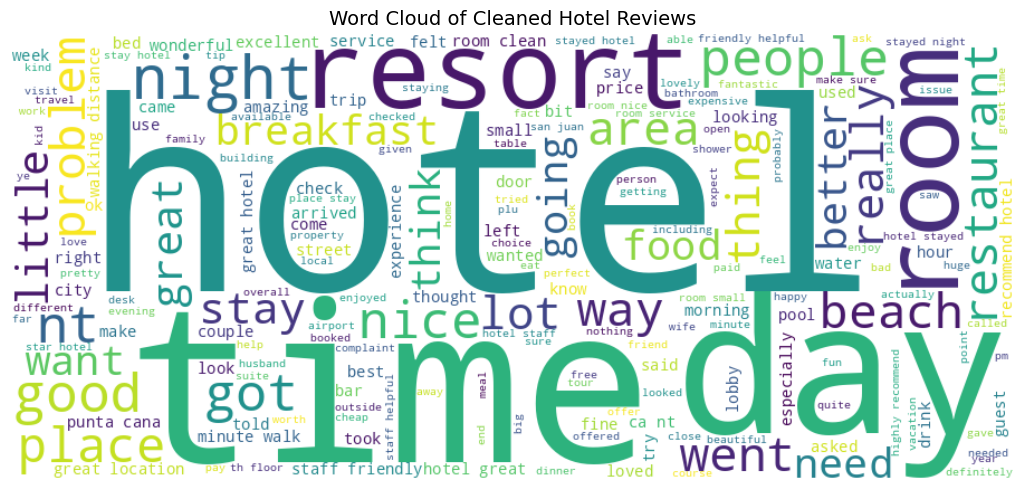

In [ ]:
text = " ".join(data['cleaned_review'])

wordcloud = WordCloud(width=900, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Hotel Reviews", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Top 20 Most Frequent Words

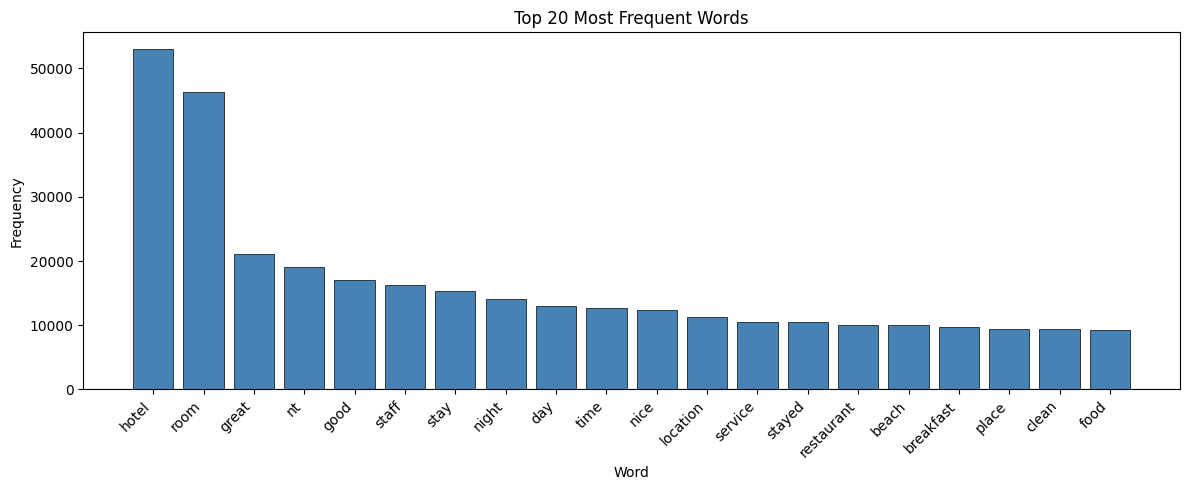

In [ ]:
all_words    = text.split()
common_words = Counter(all_words).most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 4 – Label Encoding & Train / Test Split (80 / 20)

Convert 1–5 star ratings into three sentiment classes:
- **0 – Negative** (rating ≤ 2)
- **1 – Neutral**  (rating = 3)
- **2 – Positive** (rating ≥ 4)

Split 80 % training / 20 % testing with `random_state=42`.

In [ ]:
def convert_rating(r):
    if r <= 2:
        return 0   # Negative
    elif r == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

data['sentiment'] = data['Rating'].apply(convert_rating)

X = data['cleaned_review']
y = data['sentiment']
num_classes = 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test  size: {len(X_test)}")

Train size: 16392
Test  size: 4099


### 4.1 Sentiment Class Distribution

Visualise the class imbalance — this justifies the use of `class_weight='balanced'` during training.

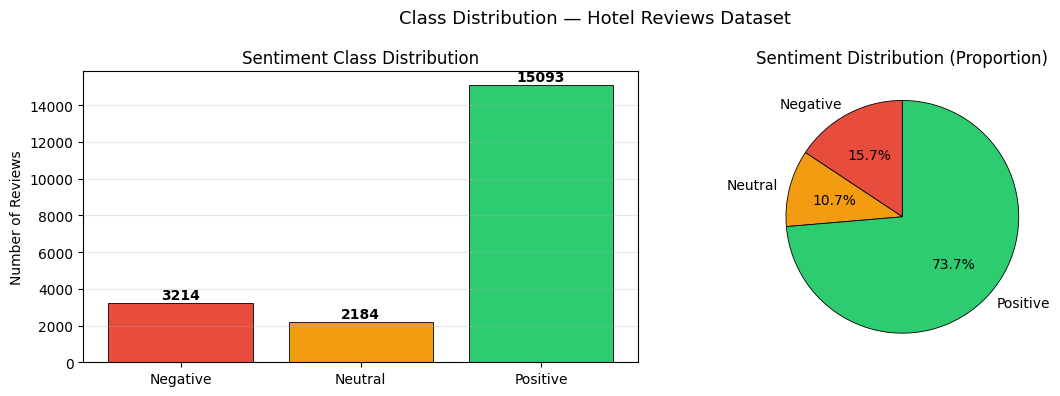

In [ ]:
label_names       = {0: "Negative", 1: "Neutral", 2: "Positive"}
sentiment_counts  = data['sentiment'].value_counts().sort_index()
labels            = [label_names[i] for i in sentiment_counts.index]
colors            = ['#e74c3c', '#f39c12', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = ax1.bar(labels, sentiment_counts.values, color=colors, edgecolor='black', linewidth=0.6)
ax1.set_title("Sentiment Class Distribution")
ax1.set_ylabel("Number of Reviews")
ax1.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, sentiment_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(sentiment_counts.values, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='black', linewidth=0.6))
ax2.set_title("Sentiment Distribution (Proportion)")

plt.suptitle("Class Distribution — Hotel Reviews Dataset", fontsize=13)
plt.tight_layout()
plt.show()

# Step 5 – Keras Tokenisation

Use `Tokenizer` to build a vocabulary of the top `vocab_size = 5000` words and convert each
review into a sequence of integer indices. The special token `<OOV>` handles out-of-vocabulary words.

In [ ]:
vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
print('Sample sequence:', X_train_seq[0][:10], '...')

Sample sequence: [592, 1052, 128, 13, 156, 8, 240, 13, 451, 3390] ...


# Step 6 – Percentile-Based Padding

Rather than padding to the maximum sequence length, we use the **90th percentile** of training
sequence lengths as `max_len`. This avoids wasteful padding from outlier-length reviews while
preserving most information. Sequences are zero-padded at the end (`padding='post'`).

In [ ]:
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 90))
print(f"90th-percentile sequence length (max_len): {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post')

print("Shape of padded train data:", X_train_pad.shape)
print("Shape of padded test  data:", X_test_pad.shape)

90th-percentile sequence length (max_len): 189
Shape of padded train data: (16392, 189)
Shape of padded test  data: (4099, 189)


# Step 7 – Class Weights

Hotel reviews are heavily skewed toward positive ratings.
`compute_class_weight('balanced')` assigns higher loss weight to minority classes
(Negative and Neutral) so the model does not simply predict Positive for every input.

In [ ]:
y_train_flat = y_train.values.flatten()
y_test_flat  = y_test.values.flatten()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(2.1104673619157976), 1: np.float64(3.1187214611872145), 2: np.float64(0.4534063563189777)}


# Step 8 – Shared Settings

In [ ]:
embedding_dim = 100

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

CLASS_LABELS = ["Negative", "Neutral", "Positive"]

---
# Model 1 – Simple RNN

A lightweight baseline:
- `Embedding(vocab_size, embedding_dim)` — trainable lookup table.
- `SimpleRNN(64)` — processes tokens sequentially.
- `Dense(32, relu)` → `Dense(3, softmax)` — classification head.

Simple RNNs are fast but can suffer from the **vanishing gradient** problem on longer sequences.

In [ ]:
model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, 189, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,739 (1.96 MB)

 Trainable params: 512,739 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model 1 – Simple RNN

In [ ]:
rnn_start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

rnn_end_time = time.time()
rnn_training_time = rnn_end_time - rnn_start_time
print(f"Training Time: {rnn_training_time:.2f} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3775 - loss: 1.1069 - val_accuracy: 0.2778 - val_loss: 1.2468
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3443 - loss: 1.1120 - val_accuracy: 0.4013 - val_loss: 1.1136
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3373 - loss: 1.1093 - val_accuracy: 0.3437 - val_loss: 1.1285
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3928 - loss: 1.1033 - val_accuracy: 0.3260 - val_loss: 1.1068
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4346 - loss: 1.0914 - val_accuracy: 0.5319 - val_loss: 1.0723
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4628 - loss: 1.0854 - val_accuracy: 0.5291 - val_loss: 1.0766
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4423 - loss: 1.0756 - val_accuracy: 0.5660 - val_loss: 1.0459
Epoch 8/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4852 - loss: 1.0630 - val_acc

## Model 1 – Training Curves

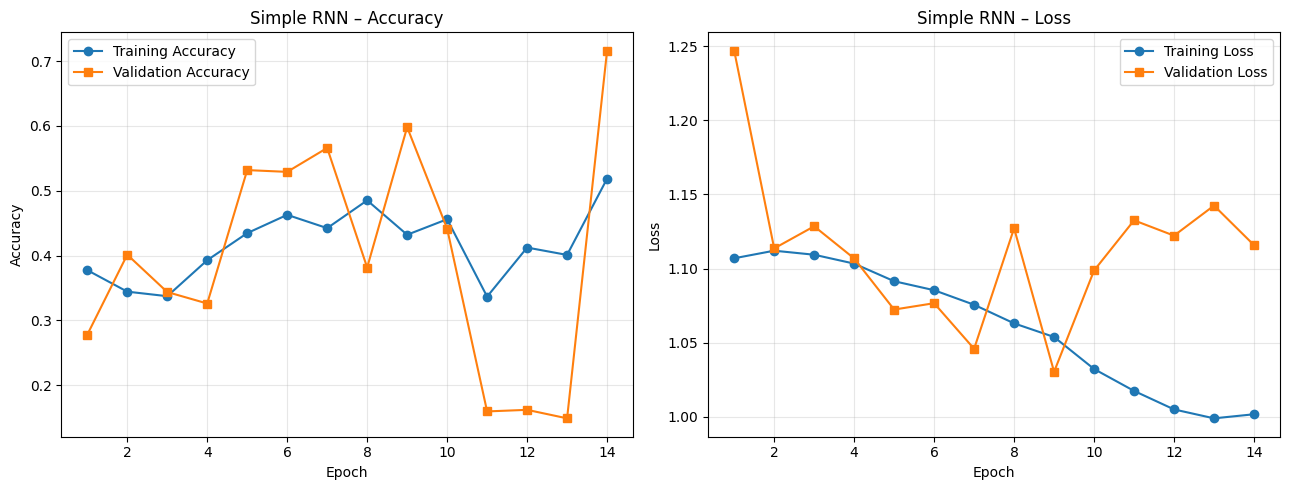

In [ ]:
plot_training_curves(history_rnn, title_prefix="Simple RNN")

## Evaluate Model 1 – Simple RNN

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

  Classification Report — Simple RNN
              precision    recall  f1-score   support

    Negative       0.35      0.06      0.10       625
     Neutral       0.13      0.32      0.18       432
    Positive       0.77      0.74      0.75      3042

    accuracy                           0.59      4099
   macro avg       0.42      0.37      0.35      4099
weighted avg       0.64      0.59      0.59      4099



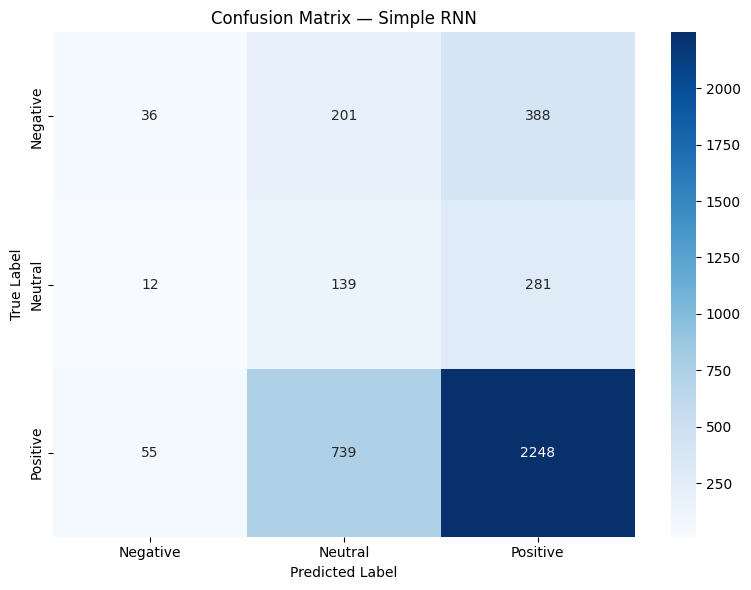

In [ ]:
rnn_preds, rnn_acc = run_evaluation(model_rnn, X_test_pad, y_test_flat, label="Simple RNN")

In [ ]:
print(f"Simple RNN Test Accuracy: {rnn_acc:.4f}")

Simple RNN Test Accuracy: 0.5911


---
# Model 2 – Bidirectional LSTM

LSTM cells use **gating mechanisms** (input, forget, output gates) to retain long-range context,
overcoming the vanishing gradient problem of Simple RNN.
The **Bidirectional** wrapper processes each sequence both forwards and backwards,
giving the model access to future context at every time step.
Dropout layers are added for regularisation.

In [ ]:
model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(vocab_size, 128),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_lstm.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ (None, 189, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 189, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 189, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,579 (3.02 MB)

 Trainable params: 792,579 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model 2 – Bidirectional LSTM

In [ ]:
lstm_start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

lstm_end_time = time.time()
lstm_training_time = lstm_end_time - lstm_start_time
print(f"Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.3330 - loss: 1.1020 - val_accuracy: 0.7033 - val_loss: 1.0697
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.4187 - loss: 1.0965 - val_accuracy: 0.7161 - val_loss: 1.1023
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.4823 - loss: 1.0721 - val_accuracy: 0.7091 - val_loss: 1.0565
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.6126 - loss: 1.0386 - val_accuracy: 0.7365 - val_loss: 1.1045
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7417 - loss: 1.0043 - val_accuracy: 0.7228 - val_loss: 1.1488
Training Time: 63.27 seconds


## Model 2 – Training Curves

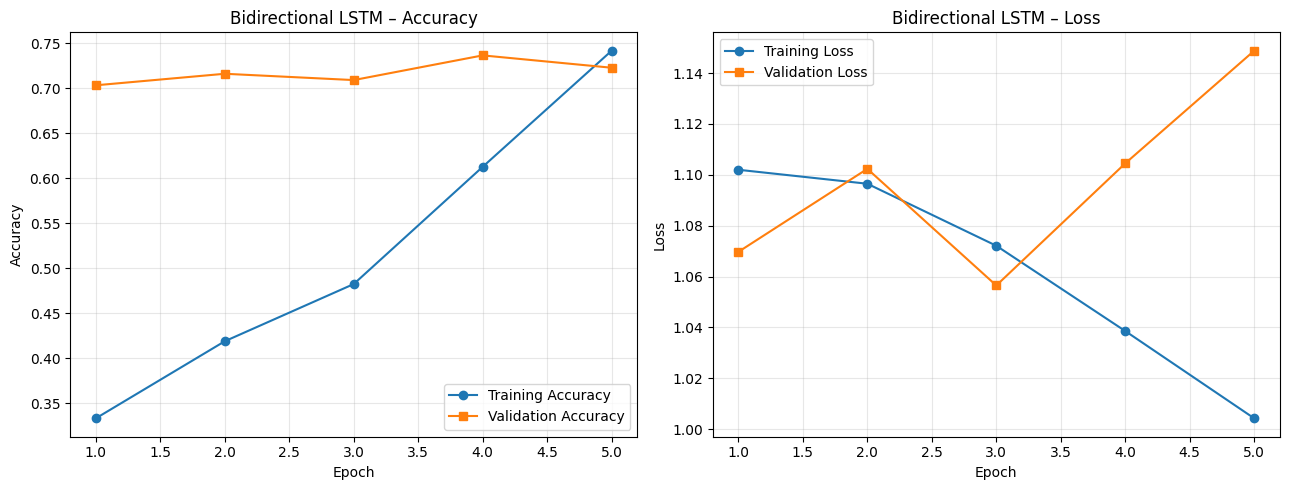

In [ ]:
plot_training_curves(history_lstm, title_prefix="Bidirectional LSTM")

## Evaluate Model 2 – Bidirectional LSTM

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

  Classification Report — Bidirectional LSTM
              precision    recall  f1-score   support

    Negative       0.28      0.04      0.07       625
     Neutral       0.17      0.12      0.14       432
    Positive       0.75      0.93      0.83      3042

    accuracy                           0.70      4099
   macro avg       0.40      0.36      0.35      4099
weighted avg       0.62      0.70      0.64      4099



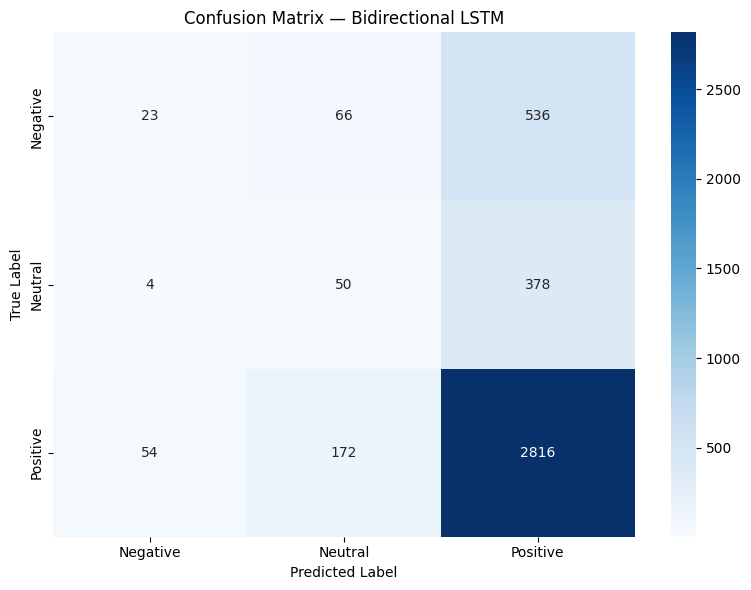

In [ ]:
lstm_preds, lstm_acc = run_evaluation(model_lstm, X_test_pad, y_test_flat, label="Bidirectional LSTM")

In [ ]:
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")

LSTM Test Accuracy: 0.7048


---# Model 3 – LSTM with Pretrained Word2Vec Embeddings

Uses **Word2Vec (word2vec-google-news-300)** pretrained word vectors loaded via `gensim.downloader`.
The embedding layer is **frozen** (`trainable=False`) so the pretrained representations are preserved.

Pretrained embeddings capture rich semantic relationships that a small trainable embedding
layer cannot learn from this dataset alone.

### Install Gensim

In [ ]:
!pip install gensim

### Load Pretrained GloVe Vectors

In [ ]:
import gensim.downloader as api

w2v_model       = api.load("word2vec-google-news-300")
embedding_dim_w2v = 300
print("word2vec model loaded.")

word2vec model loaded.


### Build the Embedding Matrix

Map every word in the Keras tokeniser vocabulary to its 300-dimensional Word2Vec vector.
Words not found in Word2Vec remain as zero vectors.

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

hits, misses = 0, 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model:
            embedding_matrix[i] = w2v_model[word]
            hits += 1
        else:
            misses += 1

print(f"Embedding hits : {hits}")
print(f"Embedding misses: {misses}")

Embedding hits : 4713
Embedding misses: 286


## Define Model 3 – LSTM + Word2Vec

In [ ]:
model_w2v = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False   # freeze pretrained weights
    ),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_w2v.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ (None, 189, 300)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,595,619 (6.09 MB)

 Trainable params: 95,619 (373.51 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

## Train Model 3 – LSTM + Word2Vec

In [ ]:
w2v_start_time = time.time()

history_w2v = model_w2v.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

w2v_end_time = time.time()
w2v_training_time = w2v_end_time - w2v_start_time
print(f"Training Time: {w2v_training_time:.2f} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.6234 - loss: 1.0982 - val_accuracy: 0.7210 - val_loss: 1.0887
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.4218 - loss: 1.0999 - val_accuracy: 0.6959 - val_loss: 1.0951
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5229 - loss: 1.0935 - val_accuracy: 0.1452 - val_loss: 1.0997
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6322 - loss: 1.0815 - val_accuracy: 0.7463 - val_loss: 1.0156
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4166 - loss: 1.0939 - val_accuracy: 0.6981 - val_loss: 1.0379
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3053 - loss: 1.0914 - val_accuracy: 0.7097 - val_loss: 1.0382
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3799 - loss: 1.0881 - val_accuracy: 0.1589 - val_loss: 1.1095
Epoch 8/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3928 - loss: 1.0790 - val_ac

## Model 3 – Training Curves

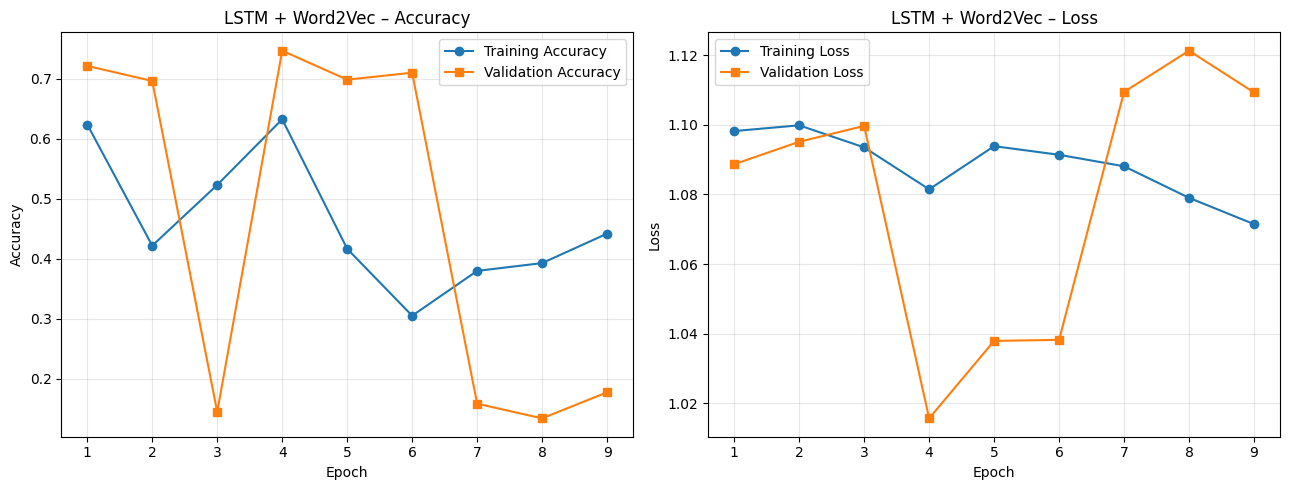

In [ ]:
plot_training_curves(history_w2v, title_prefix="LSTM + Word2Vec")

## Evaluate Model 3 – LSTM + Word2Vec

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

  Classification Report — LSTM + Word2Vec
              precision    recall  f1-score   support

    Negative       0.92      0.09      0.16       625
     Neutral       0.20      0.03      0.06       432
    Positive       0.76      0.99      0.86      3042

    accuracy                           0.75      4099
   macro avg       0.63      0.37      0.36      4099
weighted avg       0.72      0.75      0.67      4099



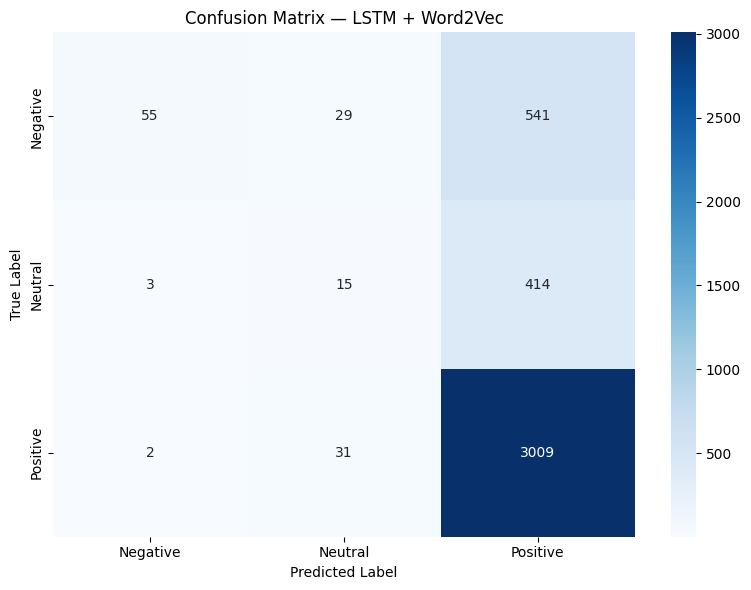

In [ ]:
w2v_preds, w2v_acc = run_evaluation(model_w2v, X_test_pad, y_test_flat, label="LSTM + Word2Vec")

In [ ]:
print(f"LSTM + Word2vec Test Accuracy: {w2v_acc:.4f}")

LSTM + Word2vec Test Accuracy: 0.7512


---
# Comparative Analysis

## All Models – Validation Curves on Same Axes

Plotting all three models' validation accuracy and loss together shows convergence speed
and relative performance at a glance.

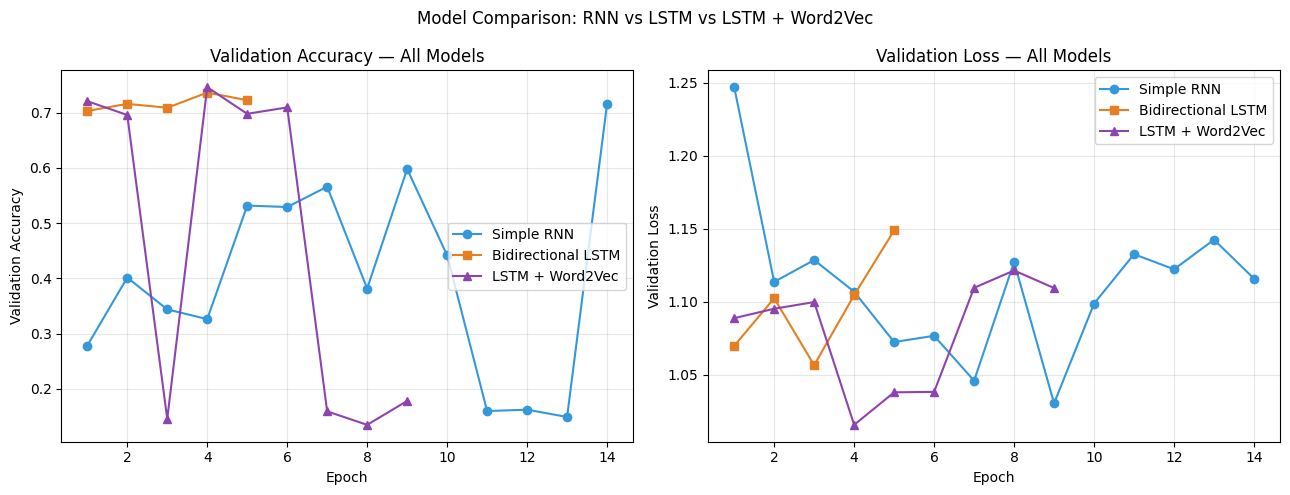

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

histories    = {
    "Simple RNN":         history_rnn,
    "Bidirectional LSTM": history_lstm,
    "LSTM + Word2Vec":       history_w2v,
}
line_colors = ['#3498db', '#e67e22', '#8e44ad']
markers     = ['o', 's', '^']

for (name, hist), color, marker in zip(histories.items(), line_colors, markers):
    ep = range(1, len(hist.history['val_accuracy']) + 1)
    ax1.plot(ep, hist.history['val_accuracy'], label=name, color=color, marker=marker, linewidth=1.5)
    ax2.plot(ep, hist.history['val_loss'],     label=name, color=color, marker=marker, linewidth=1.5)

ax1.set_title("Validation Accuracy — All Models")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Validation Loss — All Models")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Model Comparison: RNN vs LSTM vs LSTM + Word2Vec", fontsize=12)
plt.tight_layout()
plt.show()

## Final Test Accuracy – Bar Chart

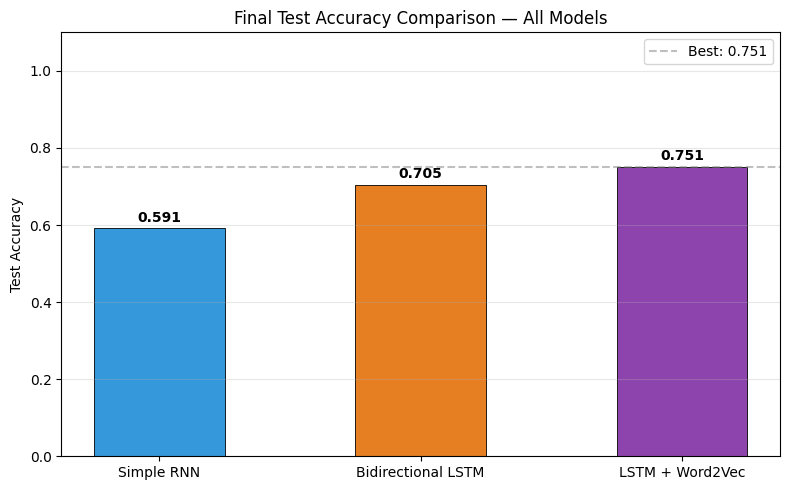

In [ ]:
rnn_acc  = accuracy_score(y_test_flat, rnn_preds)
lstm_acc = accuracy_score(y_test_flat, lstm_preds)
w2v_acc  = accuracy_score(y_test_flat, w2v_preds)

model_labels = ["Simple RNN", "Bidirectional LSTM", "LSTM + Word2Vec"]
accs         = [rnn_acc, lstm_acc, w2v_acc]
bar_colors   = ['#3498db', '#e67e22', '#8e44ad']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_labels, accs, color=bar_colors, edgecolor='black', linewidth=0.6, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Final Test Accuracy Comparison — All Models")
ax.axhline(y=max(accs), color='gray', linestyle='--', alpha=0.5, label=f"Best: {max(accs):.3f}")
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Summary Table

In [ ]:
# Get test losses for all models
rnn_test_loss  = model_rnn.evaluate(X_test_pad, y_test_flat, verbose=0)[0]
lstm_test_loss = model_lstm.evaluate(X_test_pad, y_test_flat, verbose=0)[0]
w2v_test_loss  = model_w2v.evaluate(X_test_pad, y_test_flat, verbose=0)[0]

print("\n" + "=" * 72)
print("                    FINAL SUMMARY — ALL MODELS")
print("=" * 72)
print(f"{'Model':<28} {'Test Acc':>10} {'Test Loss':>10} {'Train Time (s)':>16}")
print("-" * 72)

summary_rows = [
    ("Simple RNN",         rnn_acc,  rnn_test_loss,  rnn_training_time),
    ("Bidirectional LSTM", lstm_acc, lstm_test_loss, lstm_training_time),
    ("LSTM + GloVe",       w2v_acc,  w2v_test_loss,  w2v_training_time),
]
for name, acc, loss, t in summary_rows:
    print(f"{name:<28} {acc:>10.4f} {loss:>10.4f} {t:>16.2f}")
print("=" * 72)

best = summary_rows[np.argmax([r[1] for r in summary_rows])][0]
print(f"\nBest performing model: {best}")


                    FINAL SUMMARY — ALL MODELS
Model                          Test Acc  Test Loss   Train Time (s)
------------------------------------------------------------------------
Simple RNN                       0.5911     1.0267           107.87
Bidirectional LSTM               0.7048     1.0694            63.27
LSTM + GloVe                     0.7512     1.0089            64.53

Best performing model: LSTM + GloVe


---
# Error Analysis

We analyse misclassifications from the best model (Bidirectional LSTM) to understand
where and why the model fails.

In [ ]:
# Error Analysis — LSTM + GloVe (Best Model)
print("Error Analysis — LSTM + GloVe (Best Model)\n")

errors = np.where(w2v_preds != y_test_flat)[0]

print(f"Total misclassified: {len(errors)} / {len(y_test_flat)}")
print(f"Error rate: {len(errors)/len(y_test_flat)*100:.2f}%\n")
print("--- 3 Example Misclassifications ---\n")

for idx, err_i in enumerate(errors[:3]):
    print(f"Example {idx + 1}:")
    print(f"  Review    : {X_test.iloc[err_i][:200]}...")
    print(f"  True label: {sentiment_names[y_test_flat[err_i]]}")
    print(f"  Predicted : {sentiment_names[w2v_preds[err_i]]}")
    print("-" * 60)

Error Analysis — LSTM + GloVe (Best Model)

Total misclassified: 1020 / 4099
Error rate: 24.88%

--- 3 Example Misclassifications ---

Example 1:
  Review    : recommend hotel reviewer actually stay hotel good thing hotel location really close leidseplein shared facility filthy got look toilet floor cleaned month facility cleaned day got disgusting staff rud...
  True label: Negative
  Predicted : Positive
------------------------------------------------------------
Example 2:
  Review    : ok hotel good location stayed night way beijing rawa island hotel service room ok location great shopping restaurant probably stay opinion nice star hotel...
  True label: Neutral
  Predicted : Positive
------------------------------------------------------------
Example 3:
  Review    : great service nice pool ok beach lovely ground small room stayed day night st th quick cab ride hotel line checkin requested king bed guaranteed offered double b club level floor thrilled went ground ...
  True labe

### Discussion – Possible Reasons for Errors

1. **Ambiguous or mixed-sentiment reviews** – A reviewer may praise the location but criticise the service in the same sentence. The model sees conflicting signals and may assign the majority-sentiment class.

2. **Sarcasm and implicit sentiment** – Phrases like *"Oh great, the lift was broken again"* are negative but contain positive words (`great`). RNNs and LSTMs rarely capture sarcasm without task-specific pretraining.

3. **Short / sparse reviews** – Very brief reviews (e.g. *"Fine."*) provide little context. After stopword removal and lemmatisation, very few tokens remain, making the prediction unreliable.

4. **Neutral class underrepresentation** – Rating = 3 (Neutral) has far fewer examples. Even with class weighting the model may still confuse Neutral with Positive or Negative.

### Model Complexity vs. Performance

| Model | Parameters | Captures Long-Range | Pretrained Knowledge | Expected Accuracy |
|---|---|---|---|---|
| Simple RNN | Low | ✗ (vanishing gradient) | ✗ | Lowest |
| Bidirectional LSTM | Medium | ✓ | ✗ | Medium |
| LSTM + Word2Vec | Medium | ✓ | ✓ | Highest |

### Suggested Improvements

- Use a larger pretrained embedding (e.g. Word2Vec 300-d, FastText) or a transformer encoder (BERT) for richer word representations.
- Fine-tune the embedding layer in Model 3 after a warm-up phase (`trainable=True` after N epochs).
- Increase vocabulary size beyond 5,000 tokens to reduce out-of-vocabulary collisions.
- Apply data augmentation (back-translation, synonym replacement) to balance the Neutral class.
- Add a self-attention layer on top of the LSTM to focus on sentiment-bearing words.

---
# GUI – Real-Time Prediction with Gradio

A simple interactive interface that lets the user type a hotel review and receive an instant
sentiment prediction from the Bidirectional LSTM model.

**How it works:**
1. The input text is preprocessed with the same `preprocess_text()` pipeline used during training.
2. The cleaned text is tokenised and padded to `max_len`.
3. The Bidirectional LSTM runs inference and returns the predicted class and confidence scores.
4. Results are displayed in the Gradio UI.

In [ ]:
!pip install gradio --quiet

In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

label_map = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}

def predict_sentiment(review_text):
    """Preprocess the input text and return a sentiment prediction."""
    if not review_text.strip():
        return "Please enter a review.", {}

    cleaned    = preprocess_text(review_text)
    seq        = tokenizer.texts_to_sequences([cleaned])
    padded     = pad_sequences(seq, maxlen=max_len, padding='post')
    probs      = model_lstm.predict(padded, verbose=0)[0]
    pred_class = int(np.argmax(probs))
    confidence = {label_map[i]: float(round(probs[i], 4)) for i in range(3)}
    return label_map[pred_class], confidence


demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type a hotel review here...",
        label="Hotel Review"
    ),
    outputs=[
        gr.Text(label="Predicted Sentiment"),
        gr.Label(label="Confidence Scores", num_top_classes=3)
    ],
    title="Hotel Review Sentiment Classifier",
    description=(
        "Enter a hotel review and the Bidirectional LSTM model will predict "
        "whether the sentiment is Positive, Neutral, or Negative."
    ),
    examples=[
        ["The room was spotless and the staff were incredibly helpful. Will definitely return!"],
        ["Check-in was okay, nothing special. Room was average for the price."],
        ["Terrible experience. Noisy, dirty room and rude reception staff."],
    ],
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7b53a1dc879b6a7b7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
